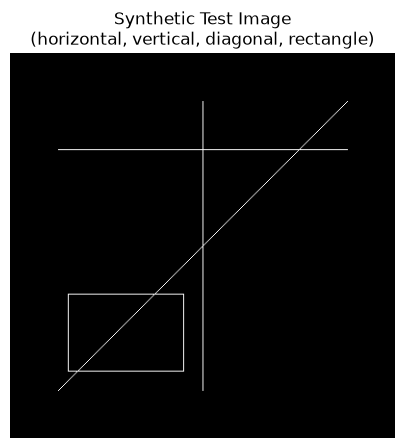

Image built. We know exactly what lines exist here —
so when Hough gives us output, we can check it against ground truth.


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

# Build a synthetic test image with KNOWN lines at KNOWN angles
# so we can directly verify Hough finds what we actually drew

canvas = np.zeros((400,400), dtype =np.uint8)

#horizontal line 
cv2.line(canvas, (50, 100), (350, 100), 255, 1)

#vertical line 
cv2.line(canvas, (200, 50), (200, 350), 255, 1)

# Diagonal line (45 degrees )
cv2.line(canvas, (50,350), (350, 50), 255, 1)

# A rectangle -> 4 more lines at 0/90 degrees , tests corner + multi-line detection 
cv2.rectangle(canvas, (60,250), (180, 330), 255, 1)

plt.figure(figsize=(5,5))
plt.imshow(canvas, cmap='gray')
plt.title('Synthetic Test Image\n(horizontal, vertical, diagonal, rectangle)')
plt.axis('off')
plt.show()

print("Image built. We know exactly what lines exist here —")
print("so when Hough gives us output, we can check it against ground truth.")

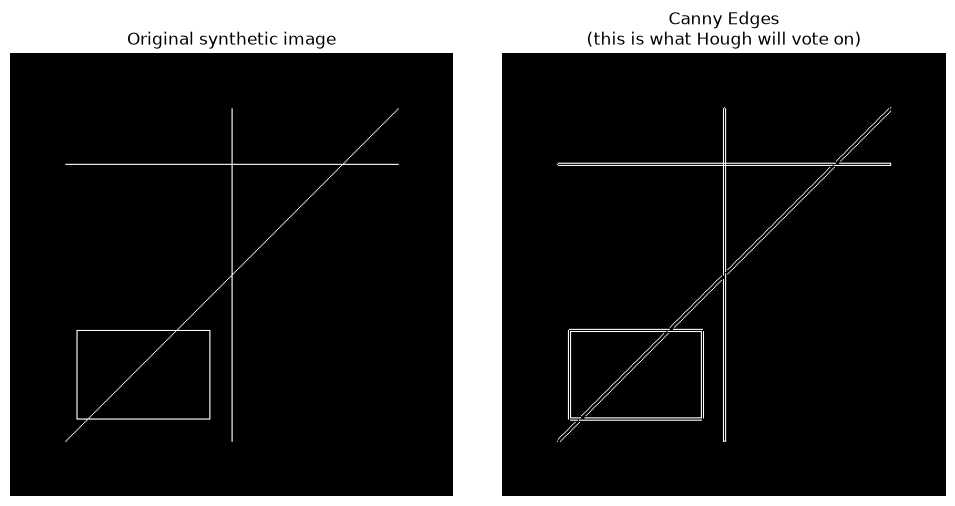

Number of edge pixels: 2540
Each of these pixels will cast votes for every possible line through it.


In [6]:
# ============================================
# Step 1: Get edge map (Hough needs edges, not raw pixels)
# ============================================

# Our canvas is already binary (0/255) with clean lines, so Canny
# will basically just trace the boundaries of what we drew.
# On a real photo this step matters a lot more (removes noise/texture).

edges = cv2.Canny(canvas, 50, 150)

fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(canvas, cmap='gray')
axes[0].set_title('Original synthetic image')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges\n(this is what Hough will vote on)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Number of edge pixels: {np.count_nonzero(edges)}")
print("Each of these pixels will cast votes for every possible line through it.")

Number of line segments detected: 14


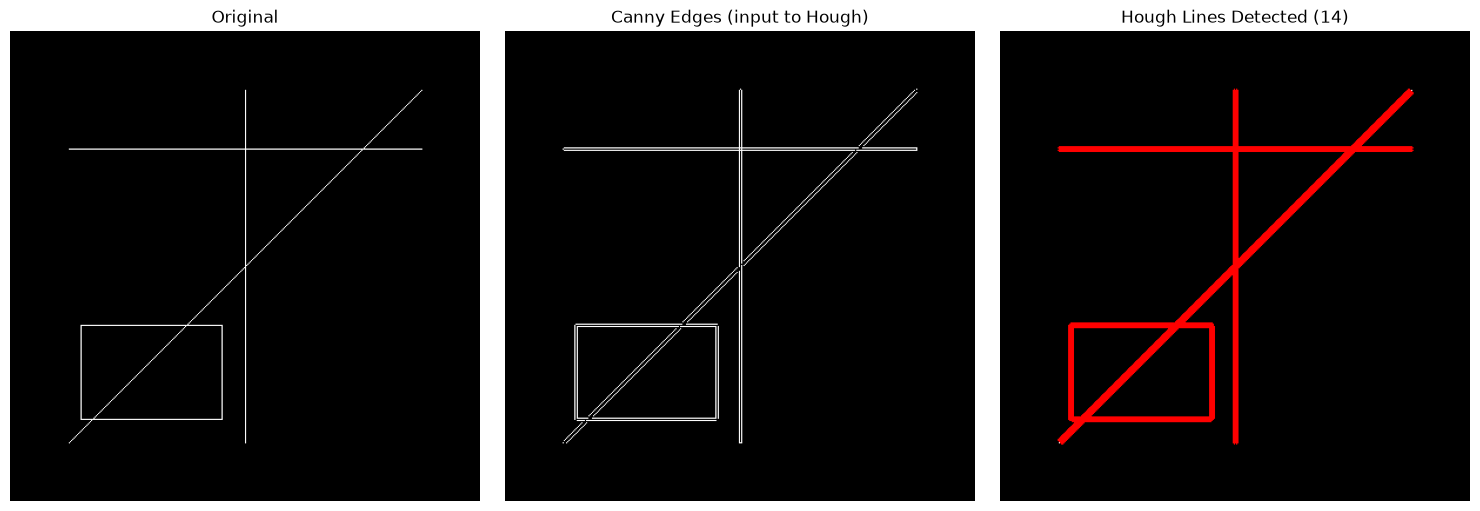

In [7]:
# ============================================
# Step 2: Hough Transform — the voting step
# ============================================

# Convert edges back to a BGR image so we can draw colored lines on it

result = cv2.cvtColor(canvas, cv2.COLOR_GRAY2BGR)

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=50,
    minLineLength=40,
    maxLineGap=10
)

print(f'Number of line segments detected: {len(lines) if lines is not None else 0}')

if lines is not None: 
    for line in lines:
        x1, y1,x2,y2 = line[0]
        cv2.line(result, (x1, y1), (x2, y2), (0, 0, 255), 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(canvas,cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges (input to Hough)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Hough Lines Detected ({len(lines) if lines is not None else 0})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# ============================================
# Debug: print every detected line's angle and length
# to see which ones are duplicates/splits vs real distinct lines
# ============================================

import math

for i, line in enumerate(lines):
    x1, y1, x2, y2 = line[0]
    length = math.hypot(x2 - x1, y2 - y1)
    angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
    print(f"Line {i:2d}: ({x1:3d},{y1:3d}) -> ({x2:3d},{y2:3d})  "
          f"length={length:6.1f}  angle={angle:6.1f}°")

Line  0: ( 50,101) -> (350,101)  length= 300.0  angle=   0.0°
Line  1: (199,350) -> (199, 50)  length= 300.0  angle= -90.0°
Line  2: ( 50,348) -> (348, 50)  length= 421.4  angle= -45.0°
Line  3: ( 52,350) -> (350, 52)  length= 421.4  angle= -45.0°
Line  4: ( 50, 99) -> (350, 99)  length= 300.0  angle=   0.0°
Line  5: (201,350) -> (201, 50)  length= 300.0  angle= -90.0°
Line  6: ( 60,249) -> (180,249)  length= 120.0  angle=   0.0°
Line  7: ( 59,251) -> (181,251)  length= 122.0  angle=   0.0°
Line  8: ( 61,331) -> (179,331)  length= 118.0  angle=   0.0°
Line  9: ( 59,329) -> (181,329)  length= 122.0  angle=   0.0°
Line 10: (181,328) -> (181,252)  length=  76.0  angle= -90.0°
Line 11: ( 59,330) -> ( 59,250)  length=  80.0  angle= -90.0°
Line 12: (179,328) -> (179,252)  length=  76.0  angle= -90.0°
Line 13: ( 61,328) -> ( 61,252)  length=  76.0  angle= -90.0°


Lines detected : 234


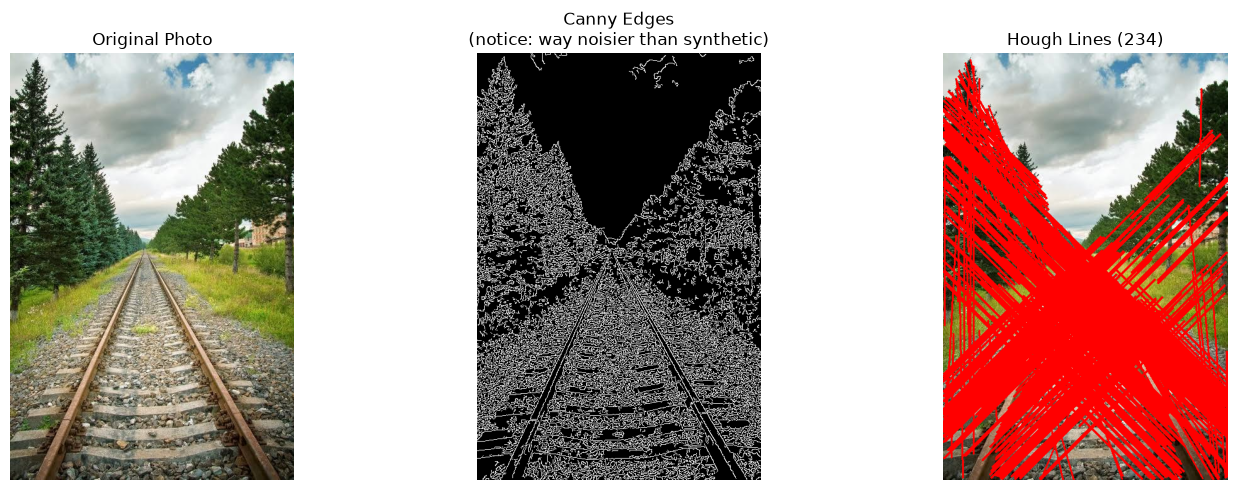

In [11]:
# ============================================
# Real photo test — same pipeline, but real images
# have much more texture noise than our synthetic canvas
# ============================================

# Load your real photo
real_img = cv2.imread('/home/arpeetpadhy/hough1.jpg')
real_gray = cv2.cvtColor(real_img, cv2.COLOR_BGR2GRAY)

# Canny on a real photo needs more thought than on clean synthetic lines --
# texture, shadows, and small surface detail all generate edge pixels
# that have nothing to do with the actual straight lines we care about

real_edges= cv2.Canny(real_gray, 100,200)     # stricter thresholds -> less texture noise

real_lines = cv2.HoughLinesP(
    real_edges,
    rho = 1, 
    theta = np.pi/180,
    threshold=150,          # up from 80 -> texture rarely accumulates this many aligned votes
    minLineLength = 100,    # up from 60 -> kills short tree-fragment segments
    maxLineGap = 15         # down from 80 -> stop stitching unrelated texture into fake long lines 
)

result_real = real_img.copy()
if real_lines is not None:
    for line in real_lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(result_real, (x1, y1), (x2,y2), (0, 0, 255),2)

print(f"Lines detected : {len(real_lines) if real_lines is not None else 0}")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Photo')
axes[0].axis('off')

axes[1].imshow(real_edges, cmap='gray')
axes[1].set_title('Canny Edges\n(notice: way noisier than synthetic)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result_real, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Hough Lines ({len(real_lines) if real_lines is not None else 0})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


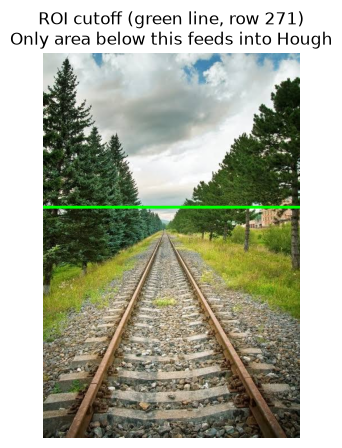

In [12]:
# ============================================
# ROI masking — restrict detection to where the rails actually are
# ============================================

h, w = real_gray.shape

# Build a mask: keep only the lower portion of the image
# (rails live roughly from 40% down to the bottom, based on the photo)
mask= np.zeros_like(real_gray)
roi_top = int(h * 0.40)
mask[roi_top:h, :] = 255 

#visualizze the ROI before applying it,so you can sanity - check the cutoff line 
roi_preview = real_img.copy()
cv2.line(roi_preview, (0, roi_top), (w, roi_top), (0,255,0), 3)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(roi_preview, cv2.COLOR_BGR2RGB))
plt.title(f'ROI cutoff (green line, row {roi_top})\nOnly area below this feeds into Hough')
plt.axis('off')
plt.show()

Lines detected : 314


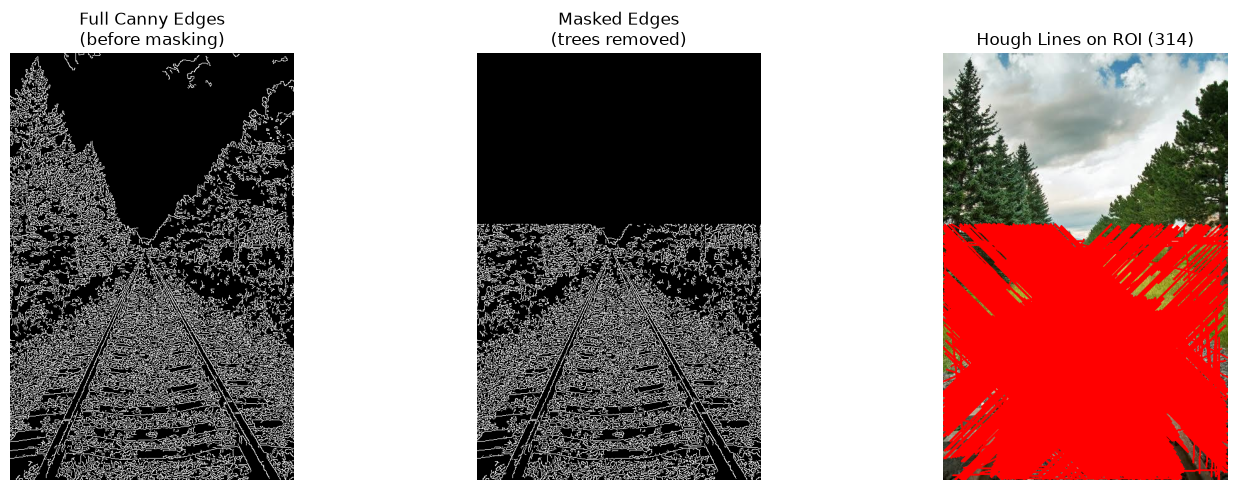

In [13]:
# ============================================
# Apply ROI mask to the edge map, then run Hough only on that region
# ============================================

# Canny on the full image first (same as before)
real_edges = cv2.Canny(real_gray, 100, 200)

# Zero out everything outside the ROI -- trees above roi_top are now invisible to Hough
masked_edges = cv2.bitwise_and(real_edges, mask)

masked_lines = cv2.HoughLinesP(
    masked_edges,
    rho=1,
    theta=np.pi/180,
    threshold=80,        # can relax back down since texture noise is mostly gone
    minLineLength=60,
    maxLineGap=20
)

result_masked = real_img.copy()
if masked_lines is not None:
    for line in masked_lines:
        x1, y1, x2,y2 = line[0]
        cv2.line(result_masked, (x1, y1), (x2, y2), (0,0,255),2)

print(f"Lines detected : {len(masked_lines) if masked_lines is not None else 0}")

fig,axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(real_edges, cmap='gray')
axes[0].set_title('Full Canny Edges\n(before masking)')
axes[0].axis('off')

axes[1].imshow(masked_edges, cmap='gray')
axes[1].set_title('Masked Edges\n(trees removed)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result_masked, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Hough Lines on ROI ({len(masked_lines) if masked_lines is not None else 0})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

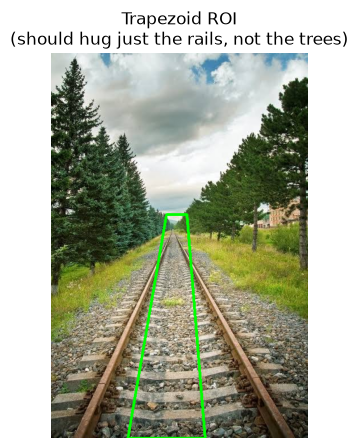

In [14]:
# ============================================
# Trapezoid ROI — follows the rails' perspective instead of a flat cutoff
# Wide at the bottom (near camera), narrow near the vanishing point
# ============================================

h, w = real_gray.shape

# Define trapezoid corners: (x, y) -- tune these based on where YOUR rails sit
vanishing_y = int(h * 0.42)          # roughly where rails converge
polygon = np.array([[
    (int(w * 0.30), h),              # bottom-left
    (int(w * 0.60), h),              # bottom-right
    (int(w * 0.53), vanishing_y),    # top-right (near vanishing point)
    (int(w * 0.45), vanishing_y),    # top-left (near vanishing point)
]], dtype=np.int32)

mask = np.zeros_like(real_gray)
cv2.fillPoly(mask, polygon, 255)

# Preview the ROI shape before applying
roi_preview = real_img.copy()
cv2.polylines(roi_preview, polygon, isClosed=True, color=(0,255,0), thickness=3)
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(roi_preview, cv2.COLOR_BGR2RGB))
plt.title('Trapezoid ROI\n(should hug just the rails, not the trees)')
plt.axis('off')
plt.show()

Lines detected: 91


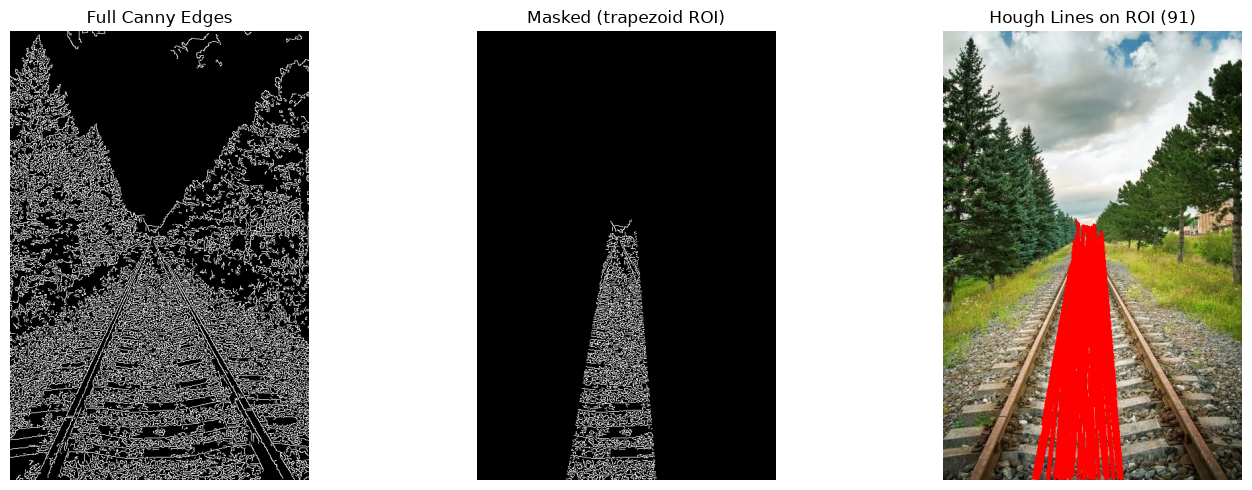

In [15]:
# ============================================
# Apply trapezoid mask to edges, then run Hough
# ============================================

real_edges = cv2.Canny(real_gray, 100, 200)
masked_edges = cv2.bitwise_and(real_edges, mask)

masked_lines = cv2.HoughLinesP(
    masked_edges,
    rho=1,
    theta=np.pi/180,
    threshold=40,        # lower again -- ROI is now tiny, fewer total edge pixels overall
    minLineLength=40,
    maxLineGap=20
)

result_masked = real_img.copy()
if masked_lines is not None:
    for line in masked_lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(result_masked, (x1, y1), (x2, y2), (0, 0, 255), 2)

print(f"Lines detected: {len(masked_lines) if masked_lines is not None else 0}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_edges, cmap='gray')
axes[0].set_title('Full Canny Edges')
axes[0].axis('off')

axes[1].imshow(masked_edges, cmap='gray')
axes[1].set_title('Masked (trapezoid ROI)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result_masked, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Hough Lines on ROI ({len(masked_lines) if masked_lines is not None else 0})')
axes[2].axis('off')

plt.tight_layout()
plt.show()